In [35]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import r2_score, root_mean_squared_error

In [37]:
salary_raw = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Educator_Salary.csv', low_memory=False)
mobility_raw = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Educator_Mobility.csv', low_memory=False)

In [38]:
salary_dropped = salary_raw.drop(columns=['Average State Salary', 'Average Local Salary', 'Average Federal Salary'])

salary_dropped['Average Total Salary'] = pd.to_numeric(
    salary_dropped['Average Total Salary'].astype(str).str.replace(',', '').str.replace('$', '', regex=False),
    errors='coerce'
)
salary_dropped['Average Years of Experience'] = pd.to_numeric(
    salary_dropped['Average Years of Experience'],
    errors='coerce'
)

def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] >= lower) & (df[col] <= upper)]

salary_clean = remove_outliers(salary_dropped, 'Average Total Salary')

salary_district = salary_clean.groupby(['School Year', 'District Code']).mean(numeric_only=True).reset_index()
mobility_district = mobility_raw.groupby(['School Year', 'District Code']).mean(numeric_only=True).reset_index()

df_merged = pd.merge(
    salary_district,
    mobility_district,
    on=['School Year', 'District Code'],
    how='inner'
)

In [39]:
target_col = 'Turnover Rate'

districts_2025 = [10, 13, 33]

target_data = df_merged[
    (df_merged['District Code'].isin(districts_2025)) &
    (df_merged['School Year'] == 2025)
]

train_data = df_merged.drop(target_data.index)

train_data = remove_outliers(train_data, target_col)

X = train_data.drop(columns=[target_col, 'School Year', 'District Code'])
y = train_data[target_col]

X_target = target_data.drop(columns=[target_col, 'School Year', 'District Code'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")
print(f"Prediction set shape: {X_target.shape}")

Training data shape: (164, 9)
Testing data shape: (41, 9)
Prediction set shape: (3, 9)


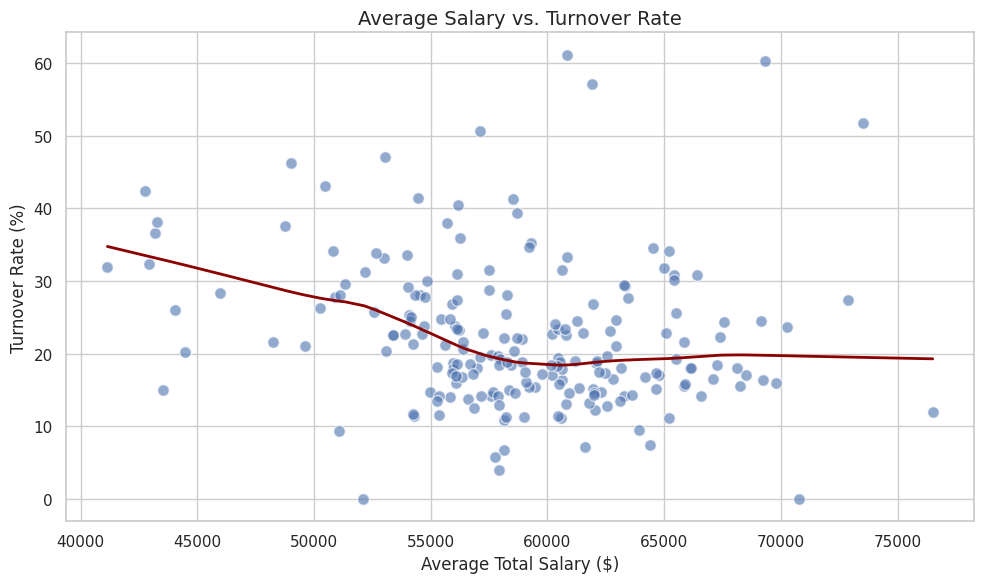

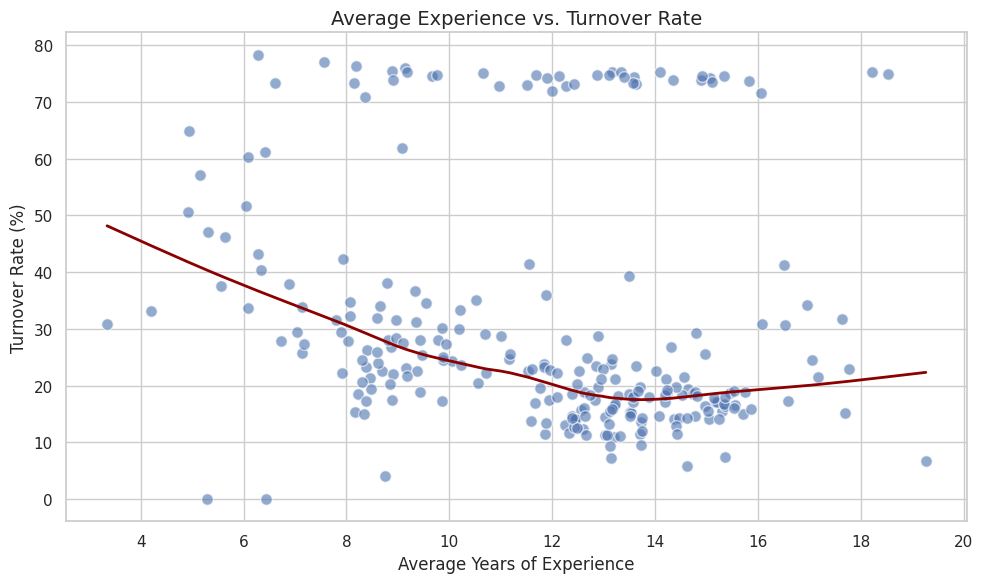

In [40]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.regplot(
    data=train_data,
    x='Average Total Salary',
    y='Turnover Rate',
    lowess=True,
    scatter_kws={'alpha': 0.6, 'edgecolor': 'w', 's': 70},
    line_kws={'color': 'darkred', 'linewidth': 2}
)
plt.title('Average Salary vs. Turnover Rate', fontsize=14)
plt.xlabel('Average Total Salary ($)', fontsize=12)
plt.ylabel('Turnover Rate (%)', fontsize=12)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.regplot(
    data=df_merged,
    x='Average Years of Experience',
    y='Turnover Rate',
    lowess=True,
    scatter_kws={'alpha': 0.6, 'edgecolor': 'w', 's': 70},
    line_kws={'color': 'darkred', 'linewidth': 2}
)
plt.title('Average Experience vs. Turnover Rate', fontsize=14)
plt.xlabel('Average Years of Experience', fontsize=12)
plt.ylabel('Turnover Rate (%)', fontsize=12)
plt.tight_layout()
plt.show()

In [41]:
models = {
    'KNN': {
        'model': KNeighborsRegressor(),
        'params': {'regressor__n_neighbors': [3, 5, 7, 10],
                   'regressor__weights': ['uniform', 'distance']}
    },
    'Decision Tree': {
        'model': DecisionTreeRegressor(random_state=42),
        'params': {'regressor__max_depth': [3, 5, 10, None],
                   'regressor__min_samples_split': [2, 5, 10]}
    },
    'Ridge': {
        'model': Ridge(),
        'params': {'regressor__alpha': [0.1, 1.0, 10.0, 100.0]}
    },
    'Lasso': {
        'model': Lasso(),
        'params': {'regressor__alpha': [0.01, 0.1, 1.0, 10.0]}
    }
}

best_models = {}

for name, config in models.items():

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', config['model'])
    ])

    grid = GridSearchCV(
        pipeline,
        config['params'],
        cv=5,
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_models[name] = grid.best_estimator_

    print(f"--- {name} ---")
    print(f"Best Params: {grid.best_params_}")
    print(f"Best CV MSE: {-grid.best_score_:.4f}\n")

--- KNN ---
Best Params: {'regressor__n_neighbors': 3, 'regressor__weights': 'distance'}
Best CV MSE: 47.9494

--- Decision Tree ---
Best Params: {'regressor__max_depth': 10, 'regressor__min_samples_split': 10}
Best CV MSE: 42.2467

--- Ridge ---
Best Params: {'regressor__alpha': 0.1}
Best CV MSE: 0.9992

--- Lasso ---
Best Params: {'regressor__alpha': 0.01}
Best CV MSE: 1.0041



In [42]:
winning_model = best_models['Ridge']

test_predictions = winning_model.predict(X_test)
r2 = r2_score(y_test, test_predictions)
rmse = root_mean_squared_error(y_test, test_predictions)

print(f"--- MODEL ACCURACY METRICS ---")
print(f"R-Squared Score: {r2 * 100:.1f}%")
print(f"Average Margin of Error (RMSE): {rmse:.2f} percentage points\n")

X_target_filled = X_target.fillna(X_train.mean())

final_predictions = winning_model.predict(X_target_filled)

target_data = target_data.reset_index(drop=True).copy()
target_data['Predicted Turnover'] = final_predictions

print("--- OFFICIAL 2025 PREDICTIONS ---")
print(target_data[['District Code', 'Predicted Turnover']])

--- MODEL ACCURACY METRICS ---
R-Squared Score: 99.0%
Average Margin of Error (RMSE): 1.00 percentage points

--- OFFICIAL 2025 PREDICTIONS ---
   District Code  Predicted Turnover
0             10           22.464580
1             13           27.958186
2             33           18.341503


In [43]:
df_clean = df_merged.copy()

df_clean = df_clean.fillna(df_clean.mean(numeric_only=True))

df_clean.to_csv('Educator_Data_CLEANED.csv', index=False)

from google.colab import files
files.download('Educator_Data_CLEANED.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>